In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("AB_NYC_2019.csv")   
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [4]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [5]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [7]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='str')

In [11]:
df[col] = df[col].fillna(df[col].mean())

In [12]:
df[col] = df[col].fillna(df[col].mode()[0])

                                      id   host_id  latitude  longitude  \
id                              1.000000  0.444947 -0.008594   0.110004   
host_id                         0.444947  1.000000  0.057380   0.119388   
latitude                       -0.008594  0.057380  1.000000   0.114510   
longitude                       0.110004  0.119388  0.114510   1.000000   
price                          -0.030985 -0.066100  0.059573  -0.398890   
minimum_nights                 -0.027144 -0.081414 -0.022662  -0.047910   
number_of_reviews              -0.175928 -0.042465  0.004493   0.010589   
reviews_per_month               0.366712  0.214298  0.002692   0.070455   
calculated_host_listings_count  0.100429  0.061882 -0.025569   0.098414   
availability_365                0.180777  0.154257 -0.006196   0.090857   

                                   price  minimum_nights  number_of_reviews  \
id                             -0.030985       -0.027144          -0.175928   
host_id         

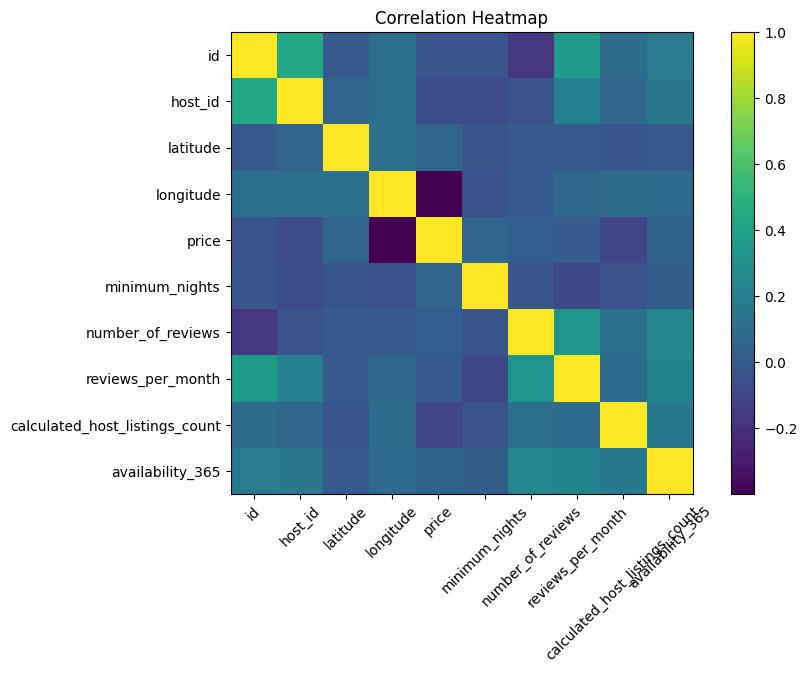

In [16]:
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)
print(corr)

plt.figure(figsize=(10,6))
plt.imshow(corr, cmap='viridis', interpolation='nearest')
plt.title("Correlation Heatmap")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.show()

In [17]:
for col in cat_cols:
    print(f"\nValue Counts for {col}:")
    print(df[col].value_counts())


Value Counts for name:
name
home away from home                                  14
private room in williamsburg                         12
brooklyn apartment                                   11
hillside hotel                                       11
private room in brooklyn                             10
                                                     ..
cozy, air-conditioned private bedroom in harlem       1
studio sized room with beautiful light                1
charming one bedroom - newly renovated rowhouse       1
affordable room in bushwick/east williamsburg         1
trendy duplex in the very heart of hell's kitchen     1
Name: count, Length: 22705, dtype: int64

Value Counts for host_name:
host_name
michael          221
david            194
sarah            170
daniel           141
alex             127
                ... 
dariné             1
toniann            1
rachel & alex      1
pirro              1
molo               1
Name: count, Length: 7181, dtype: int64

Val

In [18]:
summary = df.describe(include='all')
print(summary)

                  id                 name       host_id host_name  \
count   2.326800e+04                23268  2.326800e+04     23268   
unique           NaN                22705           NaN      7181   
top              NaN  home away from home           NaN   michael   
freq             NaN                   14           NaN       221   
mean    1.791961e+07                  NaN  4.848747e+07       NaN   
std     1.002798e+07                  NaN  6.026072e+07       NaN   
min     5.295000e+03                  NaN  2.571000e+03       NaN   
25%     9.393340e+06                  NaN  6.785099e+06       NaN   
50%     1.824013e+07                  NaN  2.334396e+07       NaN   
75%     2.606346e+07                  NaN  6.316566e+07       NaN   
max     3.648724e+07                  NaN  2.567189e+08       NaN   

       neighbourhood_group neighbourhood      latitude     longitude  \
count                23268         23268  23268.000000  23268.000000   
unique                   4 

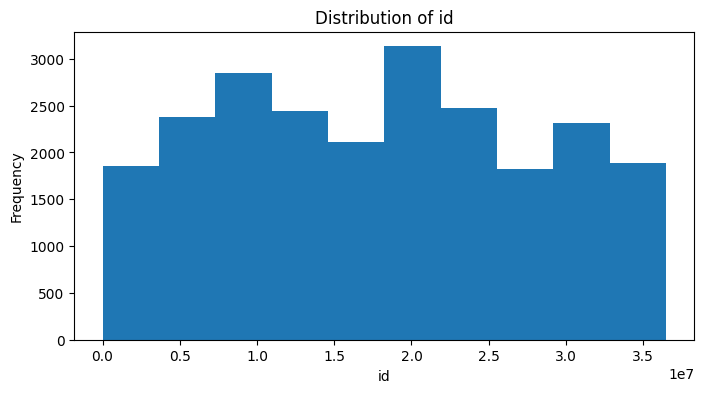

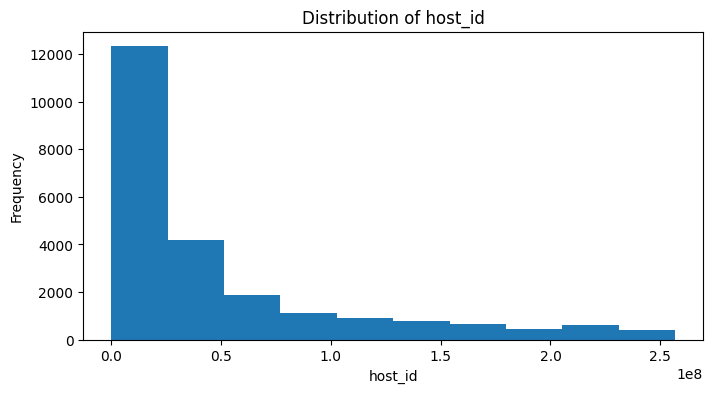

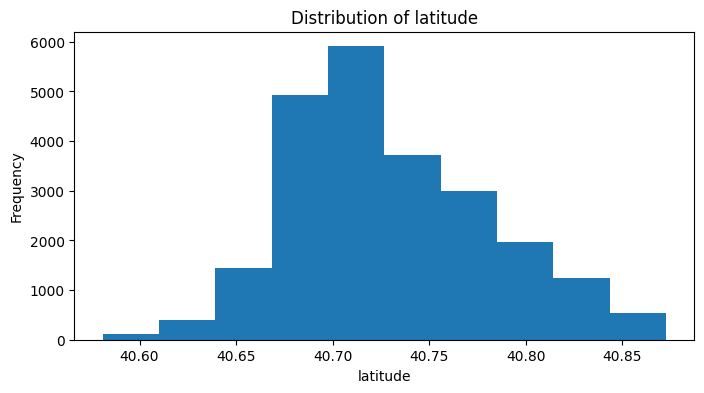

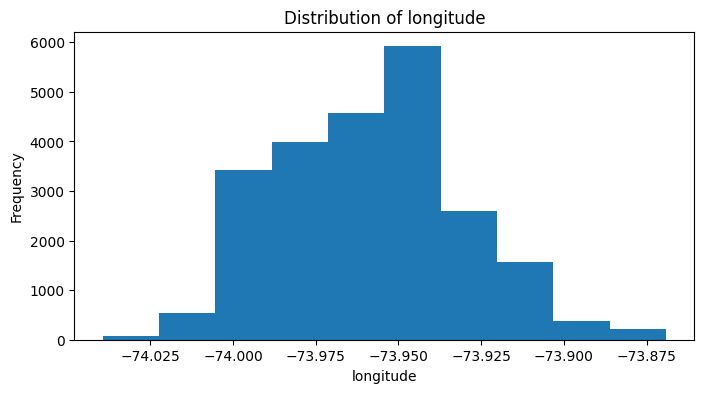

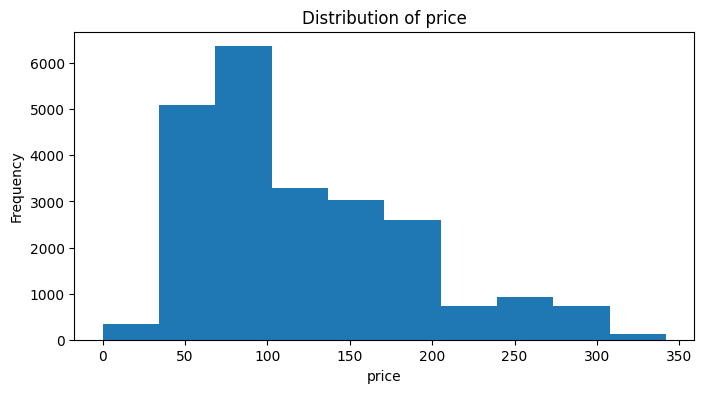

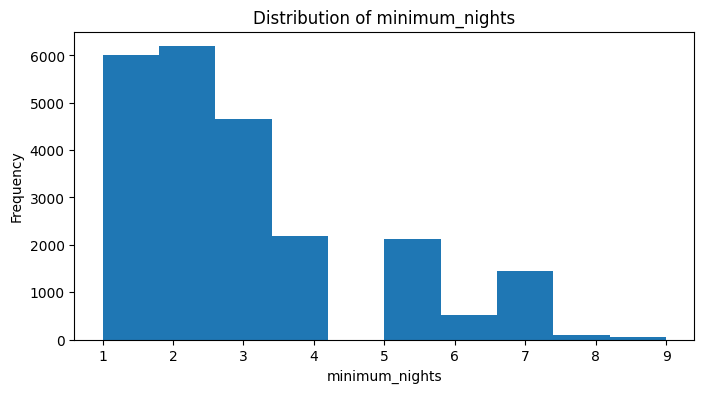

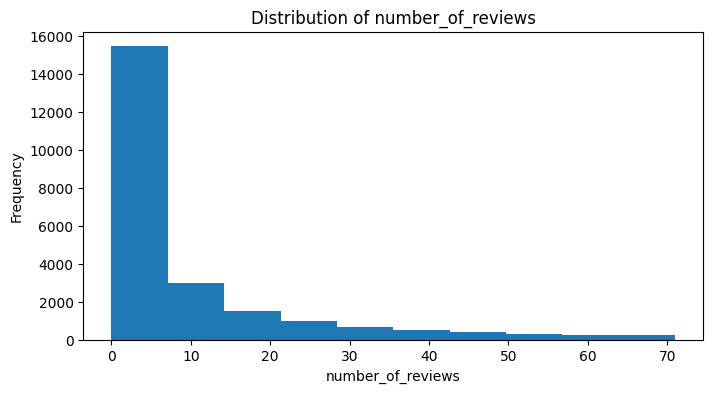

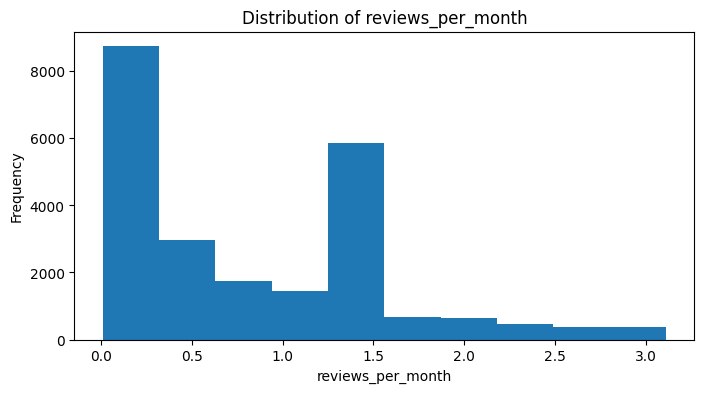

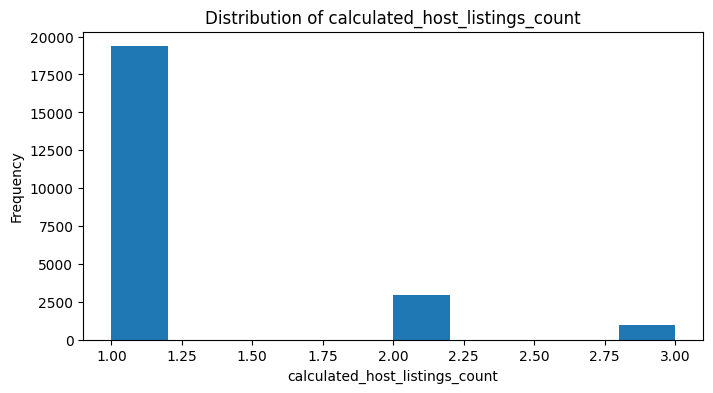

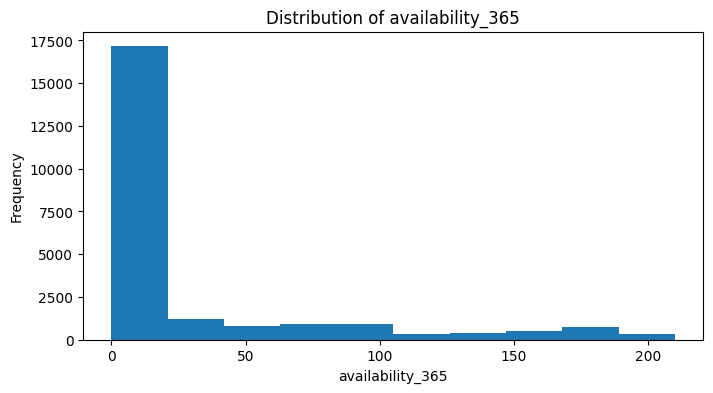

In [19]:
for col in num_cols:
    plt.figure(figsize=(8,4))
    plt.hist(df[col])
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

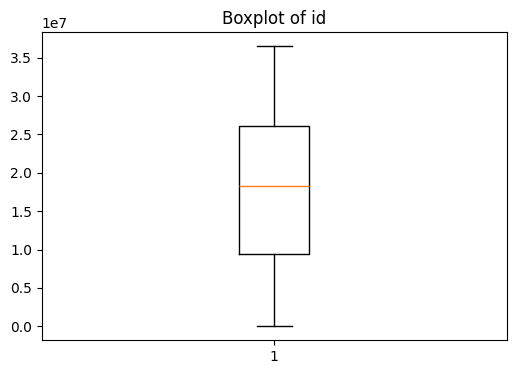

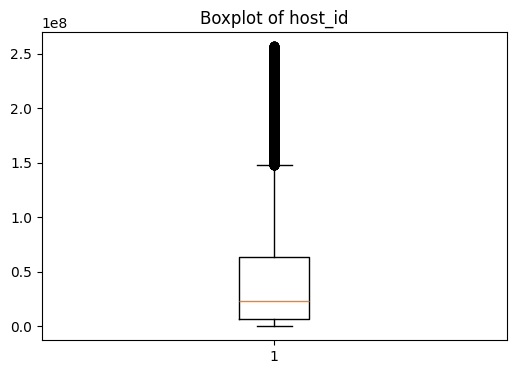

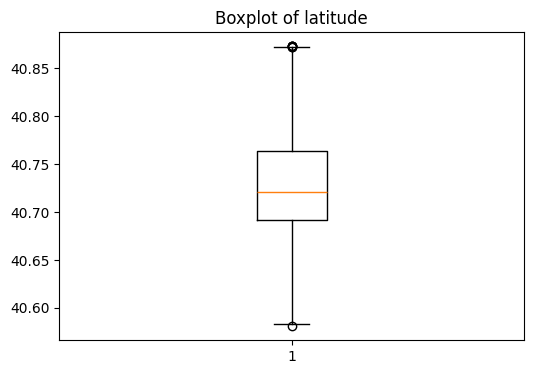

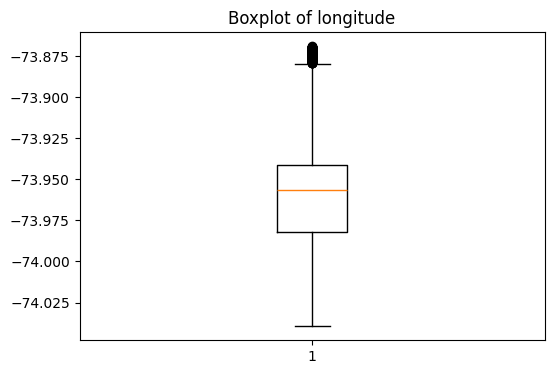

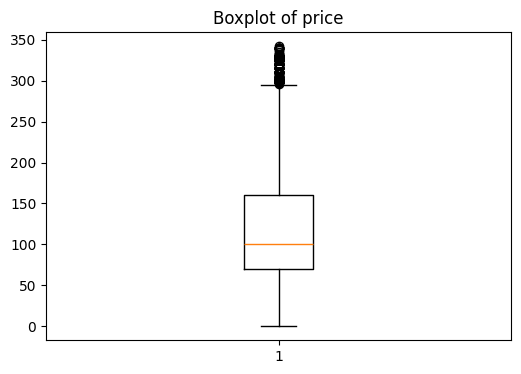

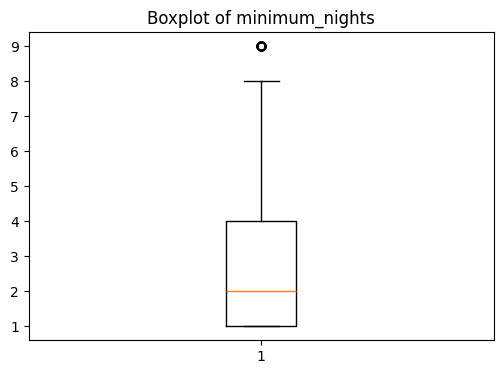

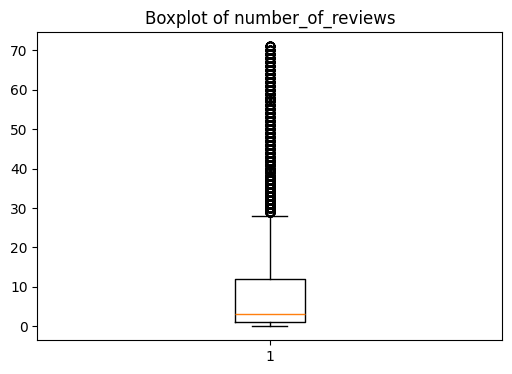

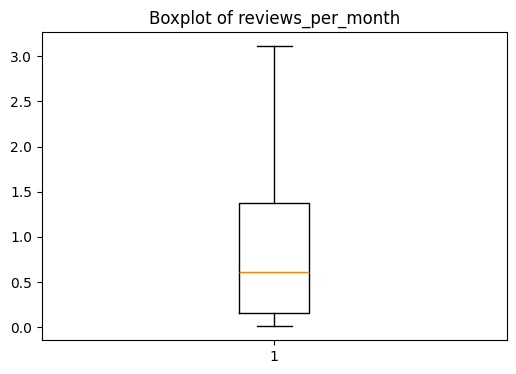

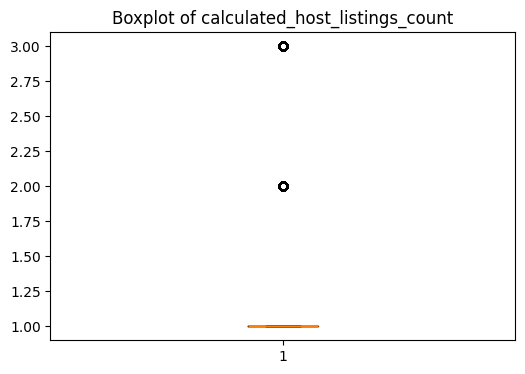

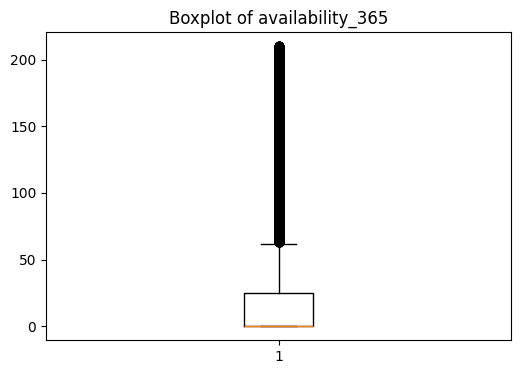

In [20]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    plt.boxplot(df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [21]:
df.to_csv("final_cleaned_dataset.csv", index=False)
print("Final cleaned dataset exported successfully!")

Final cleaned dataset exported successfully!


Conclusion

The dataset was successfully cleaned by handling missing values and analyzing the structure of the data. After cleaning, the dataset became more consistent and ready for analysis. The analysis shows that most listings are located in Brooklyn and Manhattan, and the most common room type is Entire home/apartment. Price variation is high across listings, and review activity influences availability and popularity. The cleaned dataset can now be used for further analysis or predictive modeling.



Recommendation

1. Hosts should set competitive prices based on location and demand to attract more bookings.
2. Increasing the number of reviews can improve listing visibility and trust.
3. Property owners should monitor availability to optimize occupancy throughout the year.
4. Further analysis such as price prediction or demand forecasting can help improve business decisions.